In [290]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Ruohan-Yang/Heart-Disease-Data-Set/refs/heads/main/processed.cleveland.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [291]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 33.3 KB


In [292]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


df.describe() is the function that allows us to receive a table of the stats regarding every category it would include count, mean, std, min, 25%, 50%, 75%, and the max.

In [293]:
print(df['ca'].unique())
print(df['thal'].unique())

<StringArray>
['0', '3', '2', '1', '?']
Length: 5, dtype: str
<StringArray>
['6', '3', '7', '?']
Length: 4, dtype: str


In [294]:
print((df['ca'] == '?').sum())
print((df['thal'] == '?').sum())

4
2


In [295]:
df = df[(df['ca'] != '?') & (df['thal'] != '?')]
df.shape


(297, 14)

In [296]:
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

df.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    int64  
 12  thal      297 non-null    int64  
 13  target    297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 34.8 KB


Why do we seperate X and y before the PCA/Isolation Forest?
    We seperate it because if target sneaks into X, PCA and IsolationForest which is supposed to be unsupervised, find patterns without knowing the answer which would mean it would essentially get handed the answer key. 
    If target were included, the model would use it directly instead of learning from symptoms.

In [297]:
X = df.drop('target', axis=1)
y = df['target']

In [298]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [299]:
X_scaled[:5]

array([[ 0.93618065,  0.69109474, -2.24062879,  0.75038004, -0.27644339,
         2.43042728,  1.01019851,  0.01749443, -0.69641941,  1.06896529,
         2.26414539, -0.72197605,  0.65587737],
       [ 1.3789285 ,  0.69109474,  0.87388018,  1.59626645,  0.74455507,
        -0.41145029,  1.01019851, -1.81633388,  1.43591632,  0.38177332,
         0.6437811 ,  2.47842525, -0.89422007],
       [ 1.3789285 ,  0.69109474,  0.87388018, -0.65943064, -0.35349988,
        -0.41145029,  1.01019851, -0.89941972,  1.43591632,  1.32666228,
         0.6437811 ,  1.41162482,  1.17257652],
       [-1.94168041,  0.69109474, -0.16428947, -0.09550637,  0.05104668,
        -0.41145029, -1.00341866,  1.63300986, -0.69641941,  2.09975324,
         2.26414539, -0.72197605, -0.89422007],
       [-1.49893255, -1.44697961, -1.20245913, -0.09550637, -0.83510292,
        -0.41145029,  1.01019851,  0.97807117, -0.69641941,  0.29587432,
        -0.97658319, -0.72197605, -0.89422007]])

PCA = principal component analysis 
Dimension reduction to compress many features into fewer new ones that summarize
the original data as well as possible while keeeping the most variance/spread

In [300]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23695056, 0.12349486])

After performing PCA we can see that the data was compressed and that only 36% of the original data was saved, so the 2D plot has lost its simplification meaning it is not a strong faithful summary. 

In [301]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination= 0.1, random_state=42)
predictions = iso_forest.fit_predict(X_scaled)

# -1 = anomaly, 1 = normal 
predictions

array([-1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,
        1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1, -1,
        1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [302]:
# how to count how many 1's and -1's there are 
import numpy as np 
np.unique(predictions, return_counts=True)

(array([-1,  1]), array([ 30, 267]))

In [303]:
import pandas as pd
comparison = pd.DataFrame({'predicted_anomaly': predictions, 'actual_target': y})
comparison['predicted_anomaly'].value_counts()


predicted_anomaly
 1    267
-1     30
Name: count, dtype: int64

In [304]:
# patients flagged as anomalies, how many acutally had heart diesease vs. not.
pd.crosstab(comparison['predicted_anomaly'], comparison['actual_target'])

# severity levels: 0 = no disease, 1-4 = increasing disease presence


actual_target,0,1,2,3,4
predicted_anomaly,,,,,
-1,12,2,5,7,4
1,148,52,30,28,9


What can we conclude from the table:

Looking at the -1 (30 flagged anomalies) row we can conclude that 18 (2+5+7+4) had some level of diease and 12 had no disease. 
Meaning rougly 60% of flagged anomalies actually had heart disease. 

Looking at 1 (normal) row we can conclude that 148 of the 267 had no disease, meaning most "normal" patients really were healthy. 

IsolationForest's "statistically unusual" is picking up some real signal about disease, but it's noisy meaning that it is an unsupervised guess based on raw numbers, not something that ever saw the actual diagnoses. 



Decision Tree Classifier

In this first part of the section we are going to train a tree. 

Why are we going to train it?
    We are going to train it because the tree doesn't know anything it is just an empty structure with settings. "Training" (.fit()) it will help us see the 297 patients' data and it will figure out which measurements predict heart disease. 

In [305]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state = 42)
tree.fit(X_scaled, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Matplotlib is building the font cache; this may take a moment.


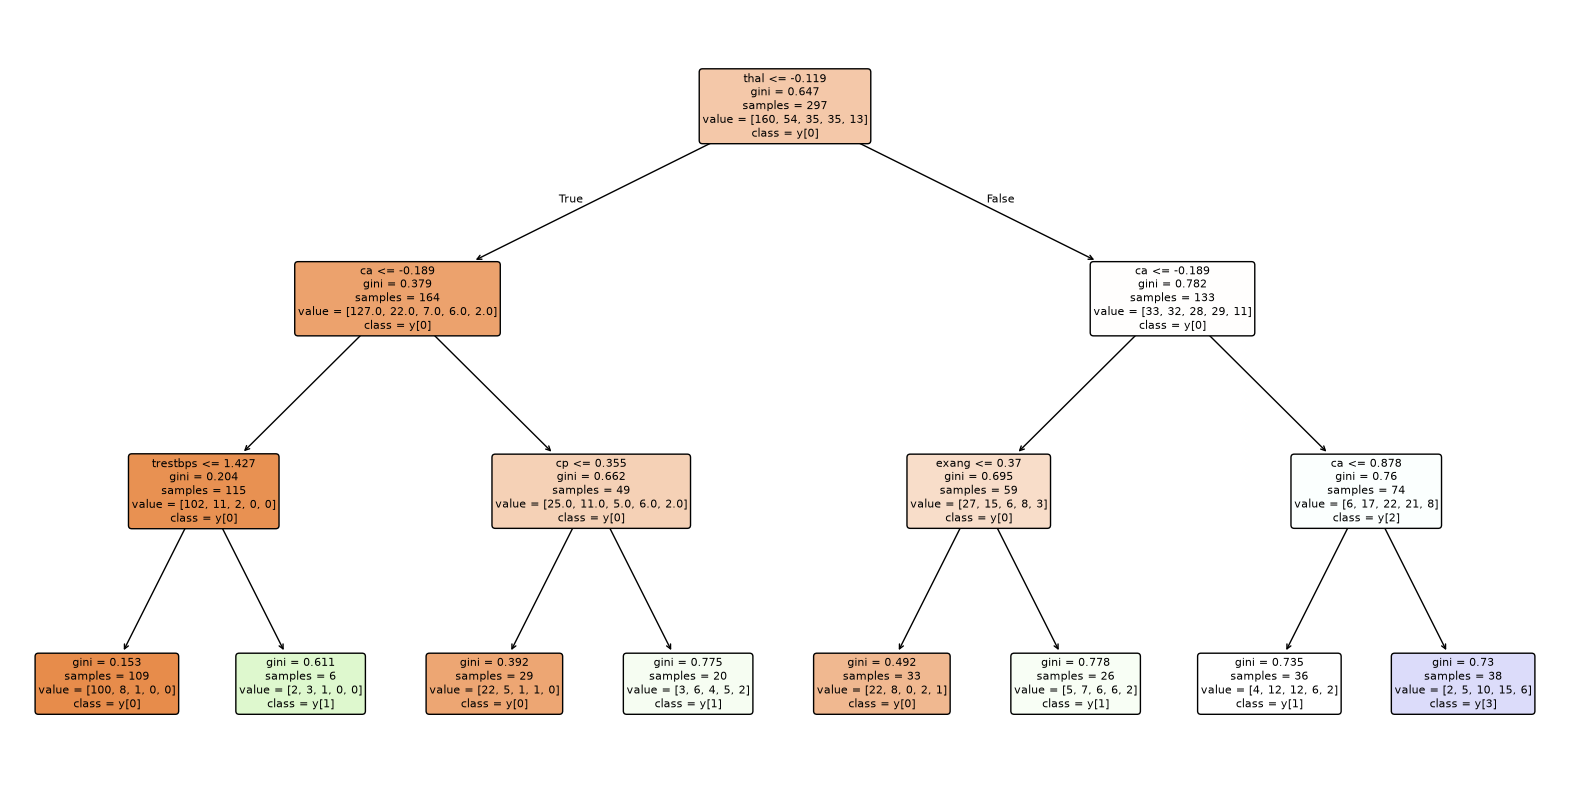

In [306]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, class_names=True, filled=True, rounded=True)
plt.show()

Why did we use a DecisionTreeClassifier and a IsolationForest?
    We used both of them because a DecisionTreeClassifier is supervised meaning it learned by looking at real diagnoses (y) and it figures out which measurements actually can predit them. 
    IsolationForest is unsupervised it never saw y at all it just looked at raw feature patterns and guess which patients looks statistically weird.